# Markov Decision Processes

A **Markov Decision Process (MDP)** is a mathematical framework for sequential decision-making under uncertainty.

At each time step, an agent observes a state, chooses an action, receives a reward, and moves to a next state. The process produces a trajectory

$$
S_0,A_0,R_1,S_1,A_1,R_2,S_2,\ldots
$$

This notebook develops the MDP framework with a 7×7 GridWorld and covers both deterministic and stochastic transitions.

## Topics

- Agent–environment interaction
- Markov property
- MDP tuple
- State and action spaces
- Transition probabilities
- Reward models
- Initial-state distribution
- Terminal states
- Deterministic and stochastic MDPs
- Policies
- Trajectories
- Return and discount factor
- State-value and action-value functions
- Bellman expectation equations
- Bellman optimality equations
- Optimal policies
- Transition matrices
- Policy-induced Markov reward processes
- Model-based vs. model-free viewpoints
- MDP vs. POMDP

## 1. Imports and Reproducibility

In [1]:
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

SEED = 42
np.random.seed(SEED)

## 2. Agent–Environment Interaction

At time step \(t\):

$$
S_t \rightarrow A_t \rightarrow (R_{t+1},S_{t+1})
$$

where:

- $S_t$: current state
- $A_t$: action selected by the agent
- $R_{t+1}$: immediate reward
- $S_{t+1}$: next state

The agent controls the action. The environment controls the resulting transition and reward.

## 3. The Markov Property

The **Markov property** states that the current state contains the information needed to describe the next-state distribution:

$$
P(S_{t+1}\mid S_t,A_t,S_{t-1},A_{t-1},\ldots)
=
P(S_{t+1}\mid S_t,A_t)
$$

This does not mean the next state must be deterministic. A stochastic process can still be Markov if the same current state and action always imply the same probability distribution over future states.

## 4. The MDP Tuple

A finite MDP is commonly represented as

$$
\mathcal{M}=(\mathcal{S},\mathcal{A},P,R,\gamma)
$$

where:

* $\mathcal{S}$: state space
* $\mathcal{A}$: action space
* $P(s'|s,a)$: transition probability
* $R(s,a,s')$: immediate reward
* $\gamma$: discount factor

An initial-state distribution may also be specified:

$$
\rho_0(s)=P(S_0=s)
$$

For episodic tasks, terminal states are defined as well.


## 5. A 7×7 GridWorld MDP

Both deterministic and stochastic examples use the same environment:

- Start: `(0, 0)`
- Goal: `(6, 6)`
- Obstacles: `(2, 2)`, `(3, 3)`, `(4, 4)`, `(5, 2)`, `(1, 5)`
- Actions: `Up`, `Down`, `Left`, `Right`
- Regular move reward: `-1`
- Obstacle attempt: stay in the current state and receive `-5`
- Goal reward: `+10`
- Boundary attempt: stay in the current state and receive `-1`

In the stochastic version, the intended direction occurs with probability 0.80 and the two perpendicular slip directions each occur with probability 0.10.

In [2]:
class GridworldMDP:
    def __init__(self, stochastic=False, gamma=0.9, seed=42):
        self.size = 7
        self.gamma = gamma
        self.stochastic = stochastic
        self.rng = np.random.default_rng(seed)

        self.start_state = (0, 0)
        self.goal_state = (6, 6)
        self.obstacles = {(2, 2), (3, 3), (4, 4), (5, 2), (1, 5)}
        self.action_space = ("Up", "Down", "Left", "Right")

        self.state_space = [
            (r, c)
            for r in range(self.size)
            for c in range(self.size)
            if (r, c) not in self.obstacles
        ]

        self.state_to_index = {s: i for i, s in enumerate(self.state_space)}
        self.index_to_state = {i: s for s, i in self.state_to_index.items()}

        self.slip_actions = {
            "Up": ("Left", "Right"),
            "Down": ("Right", "Left"),
            "Left": ("Down", "Up"),
            "Right": ("Up", "Down"),
        }

        self.state = self.start_state

    def reset(self, state=None, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        if state is None:
            state = self.start_state

        if state not in self.state_space:
            raise ValueError("Invalid reset state.")

        self.state = state
        return state

    def _move(self, state, action):
        if state == self.goal_state:
            return self.goal_state, 0, True

        r, c = state

        if action == "Up":
            candidate = (max(r - 1, 0), c)
        elif action == "Down":
            candidate = (min(r + 1, self.size - 1), c)
        elif action == "Left":
            candidate = (r, max(c - 1, 0))
        elif action == "Right":
            candidate = (r, min(c + 1, self.size - 1))
        else:
            raise ValueError("Invalid action.")

        if candidate in self.obstacles:
            return state, -5, False

        if candidate == self.goal_state:
            return candidate, 10, True

        return candidate, -1, False

    def transition_distribution(self, state, action):
        if state == self.goal_state:
            return [(1.0, self.goal_state, 0, True)]

        if not self.stochastic:
            ns, r, done = self._move(state, action)
            return [(1.0, ns, r, done)]

        slip_1, slip_2 = self.slip_actions[action]
        outcomes = [
            (0.80, action),
            (0.10, slip_1),
            (0.10, slip_2),
        ]

        aggregate = defaultdict(float)

        for probability, actual_action in outcomes:
            ns, r, done = self._move(state, actual_action)
            aggregate[(ns, r, done)] += probability

        return [
            (p, ns, r, done)
            for (ns, r, done), p in aggregate.items()
        ]

    def step(self, action):
        distribution = self.transition_distribution(self.state, action)
        probabilities = [x[0] for x in distribution]
        i = self.rng.choice(len(distribution), p=probabilities)

        probability, ns, reward, done = distribution[i]
        self.state = ns

        return ns, reward, done, {"sampled_probability": probability}

    def plot(self, title):
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(-0.5, 6.5)
        ax.set_ylim(6.5, -0.5)

        ax.set_xticks(range(7))
        ax.set_yticks(range(7))
        ax.set_xticks(np.arange(-0.5, 7, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 7, 1), minor=True)
        ax.grid(which="minor", linewidth=1)

        for r in range(7):
            for c in range(7):
                state = (r, c)

                if state in self.obstacles:
                    label = "X"
                elif state == self.start_state:
                    label = "S"
                elif state == self.goal_state:
                    label = "G"
                else:
                    label = ""

                if label:
                    ax.text(c, r, label, ha="center", va="center", fontsize=14)

        ax.set_xlabel("Column")
        ax.set_ylabel("Row")
        ax.set_title(title)
        plt.show()

Valid states: 44
Actions: ('Up', 'Down', 'Left', 'Right')
Discount factor: 0.9


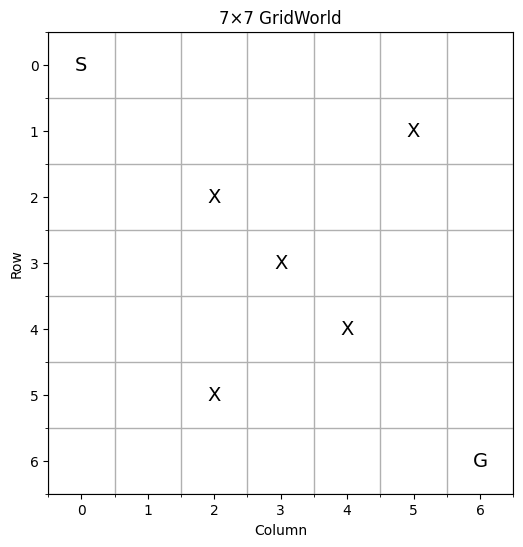

In [3]:
det_env = GridworldMDP(stochastic=False, seed=SEED)
stoch_env = GridworldMDP(stochastic=True, seed=SEED)

print("Valid states:", len(det_env.state_space))
print("Actions:", det_env.action_space)
print("Discount factor:", det_env.gamma)

det_env.plot("7×7 GridWorld")

## 6. State Space $\mathcal{S}$

A state should contain the information needed for future decisions.

Here, the state is the agent's location:

$$
s=(row,column)
$$

Obstacle cells are not valid states because the agent cannot occupy them.

In [4]:
print("First 12 states:")
print(det_env.state_space[:12])
print("\nNumber of valid states:", len(det_env.state_space))

First 12 states:
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4)]

Number of valid states: 44


## 7. Action Space $\mathcal{A}$

The action space is

$$
\mathcal{A}
=
\{\text{Up},\text{Down},\text{Left},\text{Right}\}
$$

In this environment, every non-terminal state uses the same action set. In other MDPs, the valid action set can depend on the state, written $\mathcal{A}(s)$.


In [5]:
for action in det_env.action_space:
    print(action)

Up
Down
Left
Right


## 8. Transition Model \(P(s'|s,a)\)

The transition model gives the probability of arriving in \(s'\) after taking action \(a\) in state \(s\):

$$
P(s'|s,a)
=
P(S_{t+1}=s'\mid S_t=s,A_t=a)
$$

For each state-action pair,

$$
\sum_{s'} P(s'|s,a)=1
$$

### 8.1 Deterministic Transition

In [6]:
state = (4, 1)
action = "Up"

for probability, next_state, reward, done in det_env.transition_distribution(state, action):
    print(
        f"P={probability:.2f} -> next_state={next_state}, "
        f"reward={reward}, done={done}"
    )

P=1.00 -> next_state=(3, 1), reward=-1, done=False


### 8.2 Stochastic Transition

In [7]:
distribution = stoch_env.transition_distribution(state, action)

for probability, next_state, reward, done in sorted(distribution):
    print(
        f"P={probability:.2f} -> next_state={next_state}, "
        f"reward={reward}, done={done}"
    )

print("Probability sum:", sum(x[0] for x in distribution))

P=0.10 -> next_state=(4, 0), reward=-1, done=False
P=0.10 -> next_state=(4, 2), reward=-1, done=False
P=0.80 -> next_state=(3, 1), reward=-1, done=False
Probability sum: 1.0


A deterministic MDP has one realized next state for each state-action pair. A stochastic MDP can assign nonzero probability to several next states.

## 9. Reward Model \(R\)

The immediate reward can be written as

$$
R(s,a,s')
$$

or as an expected reward

$$
r(s,a)
=
\mathbb{E}[R_{t+1}\mid S_t=s,A_t=a]
$$

Reward and return are different:

- **reward:** immediate feedback
- **return:** accumulated future reward

In [8]:
def expected_reward(env, state, action):
    return sum(
        p * reward
        for p, _, reward, _ in env.transition_distribution(state, action)
    )

state = (2, 1)
action = "Right"

print("Deterministic expected reward:",
      expected_reward(det_env, state, action))

print("Stochastic expected reward:",
      expected_reward(stoch_env, state, action))

Deterministic expected reward: -5.0
Stochastic expected reward: -4.2


## 10. Initial-State Distribution $\rho_0$

An MDP can specify the probability of starting in each state:

$$
\rho_0(s)=P(S_0=s)
$$

Here the start is fixed:

$$
\rho_0((0,0))=1
$$

and all other states have probability $0$.


In [9]:
rho_0 = {
    state: 1.0 if state == det_env.start_state else 0.0
    for state in det_env.state_space
}

print("rho_0((0,0)) =", rho_0[(0, 0)])
print("rho_0((1,0)) =", rho_0[(1, 0)])

rho_0((0,0)) = 1.0
rho_0((1,0)) = 0.0


## 11. Terminal States, Episodic Tasks, and Continuing Tasks

An **episodic task** has a natural end. In this environment, reaching `(6, 6)` ends the episode.

A complete episode can be written as

$$
S_0,A_0,R_1,\ldots,S_T
$$

where $S_T$ is terminal.

A **continuing task** has no natural terminal point, such as long-running process control or resource allocation.

In [10]:
print("Transition into goal:")
print(det_env.transition_distribution((5, 6), "Down"))

print("\nTransition requested from terminal state:")
print(det_env.transition_distribution((6, 6), "Left"))

Transition into goal:
[(1.0, (6, 6), 10, True)]

Transition requested from terminal state:
[(1.0, (6, 6), 0, True)]


## 12. Policy $\pi(a|s)$

A policy defines how the agent selects actions.

A stochastic policy is

$$
\pi(a|s)=P(A_t=a\mid S_t=s)
$$

A deterministic policy maps each state directly to one action:

$$
a=\pi(s)
$$


In [11]:
def uniform_random_policy(env, state):
    return {
        action: 1.0 / len(env.action_space)
        for action in env.action_space
    }

def simple_deterministic_policy(env, state):
    if state == env.goal_state:
        return None

    if state[0] < env.goal_state[0]:
        return "Down"

    return "Right"

state = (3, 1)

print("Uniform random policy:")
print(uniform_random_policy(det_env, state))

print("\nDeterministic policy:")
print(simple_deterministic_policy(det_env, state))

Uniform random policy:
{'Up': 0.25, 'Down': 0.25, 'Left': 0.25, 'Right': 0.25}

Deterministic policy:
Down


## 13. Policy Randomness vs. Environment Randomness

Two different probability mechanisms may exist.

### Policy stochasticity

The agent randomizes over actions:

$$
\pi(a|s)
$$

### Transition stochasticity

The environment randomizes over next states:

$$
P(s'|s,a)
$$

A deterministic policy can therefore operate in a stochastic environment.

In [12]:
state = (4, 1)
action = simple_deterministic_policy(stoch_env, state)

print("Deterministic policy chooses:", action)
print("Possible environment outcomes:")

for p, ns, reward, done in sorted(
    stoch_env.transition_distribution(state, action)
):
    print(f"P={p:.2f} -> {ns}, reward={reward}")

Deterministic policy chooses: Down
Possible environment outcomes:
P=0.10 -> (4, 0), reward=-1
P=0.10 -> (4, 2), reward=-1
P=0.80 -> (5, 1), reward=-1


## 14. Trajectories

A trajectory is

$$
\tau=(S_0,A_0,R_1,S_1,A_1,R_2,\ldots)
$$

The trajectory is generated jointly by the policy and the environment.

In [13]:
def sample_episode(env, policy_fn, max_steps=15, seed=3):
    env.reset(seed=seed)
    trajectory = []

    for t in range(max_steps):
        state = env.state

        if state == env.goal_state:
            break

        action = policy_fn(env, state)
        next_state, reward, done, _ = env.step(action)

        trajectory.append(
            (t, state, action, reward, next_state, done)
        )

        if done:
            break

    return trajectory

trajectory = sample_episode(
    stoch_env,
    simple_deterministic_policy,
    max_steps=15,
    seed=3
)

print(f"{'t':<4}{'State':<12}{'Action':<8}{'Reward':<8}{'Next':<12}{'Done'}")

for t, state, action, reward, next_state, done in trajectory:
    print(
        f"{t:<4}{str(state):<12}{action:<8}{reward:<8}"
        f"{str(next_state):<12}{done}"
    )

t   State       Action  Reward  Next        Done
0   (0, 0)      Down    -1      (1, 0)      False
1   (1, 0)      Down    -1      (2, 0)      False
2   (2, 0)      Down    -1      (2, 1)      False
3   (2, 1)      Down    -1      (3, 1)      False
4   (3, 1)      Down    -1      (4, 1)      False
5   (4, 1)      Down    -1      (5, 1)      False
6   (5, 1)      Down    -1      (6, 1)      False
7   (6, 1)      Right   -1      (6, 2)      False
8   (6, 2)      Right   -1      (6, 3)      False
9   (6, 3)      Right   -1      (6, 4)      False
10  (6, 4)      Right   -1      (6, 5)      False
11  (6, 5)      Right   10      (6, 6)      True


## 15. Return $G_t$

The return is the discounted sum of future rewards:

$$
G_t
=
R_{t+1}
+\gamma R_{t+2}
+\gamma^2R_{t+3}
+\cdots
$$

For an episodic task,

$$
G_t
=
\sum_{k=0}^{T-t-1}\gamma^kR_{t+k+1}
$$

In [14]:
def discounted_return(rewards, gamma):
    return sum(
        (gamma ** k) * reward
        for k, reward in enumerate(rewards)
    )

rewards = [row[3] for row in trajectory]

print("Observed rewards:", rewards)

for gamma in [0.0, 0.5, 0.9, 1.0]:
    print(
        f"gamma={gamma:.1f} -> "
        f"G0={discounted_return(rewards, gamma):.3f}"
    )

Observed rewards: [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 10]
gamma=0.0 -> G0=-1.000
gamma=0.5 -> G0=-1.994
gamma=0.9 -> G0=-3.724
gamma=1.0 -> G0=-1.000


## 16. Discount Factor $\gamma$

The discount factor controls the weight assigned to future rewards:

$$
0\leq\gamma\leq1
$$

* $\gamma=0$: only immediate reward matters
* small $\gamma$: short-term rewards dominate
* large $\gamma$: future rewards matter more
* $\gamma=1$: no discounting


## 17. State-Value Function $V^\pi(s)$

The state-value function is the expected return from a state while following policy $\pi$:

$$
V^\pi(s)
=
\mathbb{E}_\pi[G_t\mid S_t=s]
$$

A state's value depends on the policy used after entering that state.


In [15]:
def evaluate_uniform_random_policy(env, gamma=0.9, tolerance=1e-10, max_iterations=10000):
    values = {state: 0.0 for state in env.state_space}
    action_probability = 1.0 / len(env.action_space)

    for iteration in range(1, max_iterations + 1):
        new_values = values.copy()
        delta = 0.0

        for state in env.state_space:
            if state == env.goal_state:
                new_values[state] = 0.0
                continue

            state_value = 0.0

            for action in env.action_space:
                action_value = 0.0

                for p, ns, reward, done in env.transition_distribution(state, action):
                    future_value = 0.0 if done else values[ns]
                    action_value += p * (reward + gamma * future_value)

                state_value += action_probability * action_value

            new_values[state] = state_value
            delta = max(delta, abs(state_value - values[state]))

        values = new_values

        if delta < tolerance:
            return values, iteration

    raise RuntimeError("Policy evaluation did not converge.")

V_det, det_sweeps = evaluate_uniform_random_policy(det_env)
V_stoch, stoch_sweeps = evaluate_uniform_random_policy(stoch_env)

print("Deterministic policy evaluation:")
print("  sweeps =", det_sweeps)
print("  V^pi(5,6) =", round(V_det[(5, 6)], 3))

print("\nStochastic policy evaluation:")
print("  sweeps =", stoch_sweeps)
print("  V^pi(5,6) =", round(V_stoch[(5, 6)], 3))

Deterministic policy evaluation:
  sweeps = 216
  V^pi(5,6) = -2.263

Stochastic policy evaluation:
  sweeps = 216
  V^pi(5,6) = -2.263


## 18. Action-Value Function $Q^\pi(s,a)$

The action-value function is

$$
Q^\pi(s,a)
=
\mathbb{E}_\pi[G_t\mid S_t=s,A_t=a]
$$

For a general stochastic MDP,

$$
Q^\pi(s,a)
=
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^\pi(s')
\right]
$$


In [16]:
def q_from_v(env, values, state, action, gamma=0.9):
    q_value = 0.0

    for p, ns, reward, done in env.transition_distribution(state, action):
        future_value = 0.0 if done else values[ns]
        q_value += p * (reward + gamma * future_value)

    return q_value

state = (5, 6)

print("Deterministic Q^pi values:")
for action in det_env.action_space:
    print(
        f"{action:<5}: "
        f"{q_from_v(det_env, V_det, state, action):.3f}"
    )

print("\nStochastic Q^pi values:")
for action in stoch_env.action_space:
    print(
        f"{action:<5}: "
        f"{q_from_v(stoch_env, V_stoch, state, action):.3f}"
    )

Deterministic Q^pi values:
Up   : -8.606
Down : 10.000
Left : -7.408
Right: -3.036

Stochastic Q^pi values:
Up   : -7.929
Down : 6.956
Left : -5.787
Right: -2.290


## 19. Bellman Expectation Equation

The Bellman expectation equation for the state-value function is

$$
V^\pi(s)
=
\sum_a
\pi(a|s)
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^\pi(s')
\right]
$$

The equation says:

$$
\text{current value}
=
\text{expected immediate reward}
+
\text{discounted expected future value}
$$

In [17]:
state = (5, 6)
policy = uniform_random_policy(stoch_env, state)

rhs = 0.0

for action, action_probability in policy.items():
    q_value = q_from_v(
        stoch_env,
        V_stoch,
        state,
        action
    )
    rhs += action_probability * q_value

print("State:", state)
print("Bellman RHS:", round(rhs, 10))
print("Stored V^pi:", round(V_stoch[state], 10))
print("Absolute difference:", abs(rhs - V_stoch[state]))

State: (5, 6)
Bellman RHS: -2.2626147601
Stored V^pi: -2.2626147601
Absolute difference: 2.5649704582519917e-11


The action-value version is

$$
Q^\pi(s,a)
=
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma
\sum_{a'}
\pi(a'|s')
Q^\pi(s',a')
\right]
$$

## 20. Optimal Value Functions

The optimal state-value function is

$$
V^*(s)=\max_\pi V^\pi(s)
$$

and satisfies

$$
V^*(s)
=
\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^*(s')
\right]
$$

The optimal action-value function is

$$
Q^*(s,a)=\max_\pi Q^\pi(s,a)
$$

and satisfies

$$
Q^*(s,a)
=
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma
\max_{a'}Q^*(s',a')
\right]
$$

## 21. Optimal Policy

An optimal policy chooses an action that maximizes expected long-term return:

$$
\pi^*(s)
\in
\arg\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^*(s')
\right]
$$

There can be more than one optimal action in a state.

In [18]:
state = (5, 6)

q_values = {
    action: q_from_v(stoch_env, V_stoch, state, action)
    for action in stoch_env.action_space
}

best_action = max(q_values, key=q_values.get)

print("Greedy action with respect to the evaluated V^pi:")
for action, value in q_values.items():
    print(f"{action:<5}: {value:.3f}")

print("\nSelected action:", best_action)

Greedy action with respect to the evaluated V^pi:
Up   : -7.929
Down : 6.956
Left : -5.787
Right: -2.290

Selected action: Down


The cell above demonstrates a **greedy backup with respect to the evaluated policy values**. It is not a full solution for $V^*$. Repeated Bellman optimality backups over all states lead to methods such as value iteration.

## 22. Transition Matrix Representation

For a finite MDP, each action can be represented by a transition matrix:

$$
P^a_{ij}
=
P(S_{t+1}=s_j\mid S_t=s_i,A_t=a)
$$

Each matrix has shape

$$
|\mathcal{S}|\times|\mathcal{S}|
$$

and each row must sum to 1.

In [19]:
def transition_matrix_for_action(env, action):
    n = len(env.state_space)
    matrix = np.zeros((n, n))

    for state in env.state_space:
        i = env.state_to_index[state]

        for p, ns, _, _ in env.transition_distribution(state, action):
            j = env.state_to_index[ns]
            matrix[i, j] += p

    return matrix

P_right = transition_matrix_for_action(stoch_env, "Right")

print("P^Right shape:", P_right.shape)
print("All rows sum to 1:", np.allclose(P_right.sum(axis=1), 1.0))

P^Right shape: (44, 44)
All rows sum to 1: True


For all actions together, the transition model can be stored as a three-dimensional tensor:

$$
P[a,i,j]
$$

with shape

$$
|\mathcal{A}|\times|\mathcal{S}|\times|\mathcal{S}|
$$

In [20]:
transition_tensor = np.stack(
    [
        transition_matrix_for_action(stoch_env, action)
        for action in stoch_env.action_space
    ],
    axis=0
)

print("Transition tensor shape:", transition_tensor.shape)

Transition tensor shape: (4, 44, 44)


## 23. Expected Reward Vector

For a fixed action,

$$
r^a(s)
=
\sum_{s'}
P(s'|s,a)R(s,a,s')
$$

In [21]:
def reward_vector(env, action):
    vector = np.zeros(len(env.state_space))

    for state in env.state_space:
        i = env.state_to_index[state]
        vector[i] = expected_reward(env, state, action)

    return vector

r_right = reward_vector(stoch_env, "Right")

for state in [(0, 0), (2, 1), (5, 6)]:
    i = stoch_env.state_to_index[state]
    print(f"r^Right({state}) = {r_right[i]:.3f}")

r^Right((0, 0)) = -1.000
r^Right((2, 1)) = -4.200
r^Right((5, 6)) = 0.100


## 24. Policy-Induced Markov Reward Process

Once a policy is fixed, the MDP becomes a **Markov Reward Process (MRP)**.

The policy-induced transition model is

$$
P^\pi(s,s')
=
\sum_a
\pi(a|s)P(s'|s,a)
$$

and the policy-induced expected reward is

$$
r^\pi(s)
=
\sum_a
\pi(a|s)
\sum_{s'}
P(s'|s,a)R(s,a,s')
$$

The Bellman equation can then be written in vector form:

$$
V^\pi
=
r^\pi
+
\gamma P^\pi V^\pi
$$

or

$$
(I-\gamma P^\pi)V^\pi=r^\pi
$$

For finite continuing formulations where the inverse exists,

$$
V^\pi
=
(I-\gamma P^\pi)^{-1}r^\pi
$$

In [22]:
def policy_transition_matrix(env):
    n = len(env.state_space)
    P_pi = np.zeros((n, n))
    action_probability = 1.0 / len(env.action_space)

    for state in env.state_space:
        i = env.state_to_index[state]

        for action in env.action_space:
            for p, ns, _, _ in env.transition_distribution(state, action):
                j = env.state_to_index[ns]
                P_pi[i, j] += action_probability * p

    return P_pi

P_pi = policy_transition_matrix(stoch_env)

print("P^pi shape:", P_pi.shape)
print("All rows sum to 1:", np.allclose(P_pi.sum(axis=1), 1.0))

P^pi shape: (44, 44)
All rows sum to 1: True


## 25. Deterministic vs. Stochastic MDP

| Property | Deterministic MDP | Stochastic MDP |
|---|---|---|
| Next state | Fixed | Random |
| $P(s'|s,a)$ | One outcome has probability 1 | Several outcomes may have nonzero probability |
| Repeated state-action pair | Same realized transition | Same probability distribution |
| Bellman backup | One next-state term | Probability-weighted expectation |
| Example | exact movement | slippery or uncertain movement |

## 26. Model-Based vs. Model-Free Methods

The MDP describes the decision problem. A learning algorithm can use it in different ways.

### Model-based

The agent has or learns a model of

$$
P(s'|s,a)
$$

and possibly

$$
R(s,a,s')
$$

and uses the model for planning.

### Model-free

The agent does not need an explicit transition model. It can learn values or policies directly from experience.

Examples include:

- Monte Carlo methods
- SARSA
- Q-learning
- policy-gradient methods

The environment can be deterministic or stochastic in either case.

## 27. Fully Observable MDP vs. POMDP

An MDP assumes the available state is sufficient for the Markov property.

If the true state is hidden and the agent receives only partial observations, the problem may be modeled as a **Partially Observable Markov Decision Process (POMDP)**.

A POMDP adds observations and an observation model. The agent may then need to reason about a belief over possible underlying states.

## 28. Designing an MDP

When defining a decision problem, ask:

### State
What information must the agent know to make future decisions?

### Action
What decisions can the agent actually control?

### Transition
What happens after an action? Is the transition deterministic or stochastic?

### Reward
What immediate behavior should be encouraged or penalized?

### Terminal condition
When does an episode end?

### Discount factor
How much should future rewards matter?

### Initial state
Where can an episode begin?

These choices define the mathematical problem before any RL algorithm is selected.

## 29. Final Summary

An MDP is defined by

$$
\mathcal{M}
=
(\mathcal{S},\mathcal{A},P,R,\gamma)
$$

with an optional initial-state distribution \(\rho_0\).

The core quantities are:

$$
P(s'|s,a)
$$

for transitions,

$$
R(s,a,s')
$$

for immediate reward,

$$
\pi(a|s)
$$

for behavior,

$$
V^\pi(s)
$$

for expected return from a state,

and

$$
Q^\pi(s,a)
$$

for expected return from a state-action pair.

The Bellman expectation equation evaluates a policy:

$$
V^\pi(s)
=
\sum_a\pi(a|s)
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^\pi(s')
\right]
$$

The Bellman optimality equation describes optimal decision-making:

$$
V^*(s)
=
\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V^*(s')
\right]
$$

The same framework handles deterministic and stochastic environments. The difference lies in the transition probabilities, not in the definition of the MDP itself.